In [21]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from enum import Enum, auto
from tqdm import tqdm
from statistics import mean

In [22]:
class ImmunisationStrategy(Enum):
    RANDOM = auto()
    TARGETED = auto()

In [23]:
# Constants
NUM_NODES = 50
NUM_EDGES = 3
NUM_SIMULATIONS = 100
NUM_TIME_STEPS = 1000
BETA = 0.3
GAMMA = 0.6
G_VALUES = list(np.linspace(0, 1, 10))

In [24]:
def find_largest_neighbor(graph, node):
    """Finds the largest neighbor of a given node based on degree."""
    neighbors = list(graph.neighbors(node))
    return max(neighbors, key=lambda n: graph.degree(n), default=None) if neighbors else None

def simulate_infection_with_immunity(network, infection_rate, recovery_rate, initial_infected_node, immune_nodes):
    """Simulates the infection process in the network considering immune nodes."""
    infected = {initial_infected_node}
    probabilities_infected_list = []
    for _ in range(NUM_TIME_STEPS):
        infected = update_infected_set(network, infected, immune_nodes, infection_rate, recovery_rate)
        probabilities_infected_list.append(len(infected) / len(network.nodes()))

    return mean(probabilities_infected_list) if probabilities_infected_list else 0

In [25]:
def update_infected_set(network, infected, immune_nodes, infection_rate, recovery_rate):
    """Updates the set of infected nodes at each time step."""
    new_infected = infected.copy()
    for infected_node in infected:
        if np.random.rand() < recovery_rate:
            new_infected.remove(infected_node)
        infect_neighbors(network, infected_node, new_infected, immune_nodes, infection_rate)
    return new_infected

def infect_neighbors(network, node, infected, immune_nodes, infection_rate):
    """Attempts to infect the neighbors of a given node."""
    for neighbor in set(network.neighbors(node)).difference(infected, immune_nodes):
        if np.random.rand() < infection_rate:
            infected.add(neighbor)

In [26]:

def select_immune_nodes(graph, fraction, strategy):
    """Selects a set of immune nodes based on the specified strategy."""
    if not graph.nodes:
        return set()

    graph_nodes = list(graph.nodes())
    np.random.shuffle(graph_nodes)
    num_node_selection = int(fraction * len(graph.nodes()))
    if strategy == ImmunisationStrategy.RANDOM:
        return set(np.random.choice(graph_nodes, num_node_selection, replace=False))

    # For TARGETED, avoid calling find_largest_neighbor twice
    return {find_largest_neighbor(graph, node) for node in graph_nodes[:num_node_selection] if find_largest_neighbor(graph, node)}
   

In [27]:
def perform_infection_simulations_with_immunity(graph, strategy):
    """Performs multiple infection simulations with a given immunization strategy."""
    probabilities_infected = []
    for g in tqdm(G_VALUES, desc=f"Progress {strategy} strategy: "):
        immune_nodes = select_immune_nodes(graph, g, strategy)
        probabilities_avg = [simulate_infection_with_immunity(graph, BETA, GAMMA, np.random.choice(list(graph.nodes())), immune_nodes) for _ in range(NUM_SIMULATIONS)]
        probabilities_infected.append(mean(probabilities_avg))
    return probabilities_infected

In [28]:
def generate_barabasi_albert_graph():
    """Generates a Barabási-Albert graph and performs immunization simulations."""
    graph = nx.barabasi_albert_graph(n=NUM_NODES, m=NUM_EDGES)
    immunity_random = perform_infection_simulations_with_immunity(graph, ImmunisationStrategy.RANDOM)
    immunity_targeted = perform_infection_simulations_with_immunity(graph, ImmunisationStrategy.TARGETED)
    return immunity_random, immunity_targeted

In [29]:
def plot_sis_sim():
    """Plots the results of the SIS model simulations."""
    immunity_random, immunity_targeted = generate_barabasi_albert_graph()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set(title="SIS Simulation: Random vs Targeted Immunization", xlabel="g", ylabel=r"$p^I(t \approx \infty)$", ylim=(0, 1), xlim=(0, 1))
    ax.plot(G_VALUES, immunity_random, label="Random", linestyle='-', color='blue', marker="o", ms=2)
    ax.plot(G_VALUES, immunity_targeted, label="Targeted", linestyle='--', color='green', marker="o", ms=2)

Progress ImmunisationStrategy.TARGETED strategy: 100%|██████████| 10/10 [00:37<00:00,  3.75s/it]


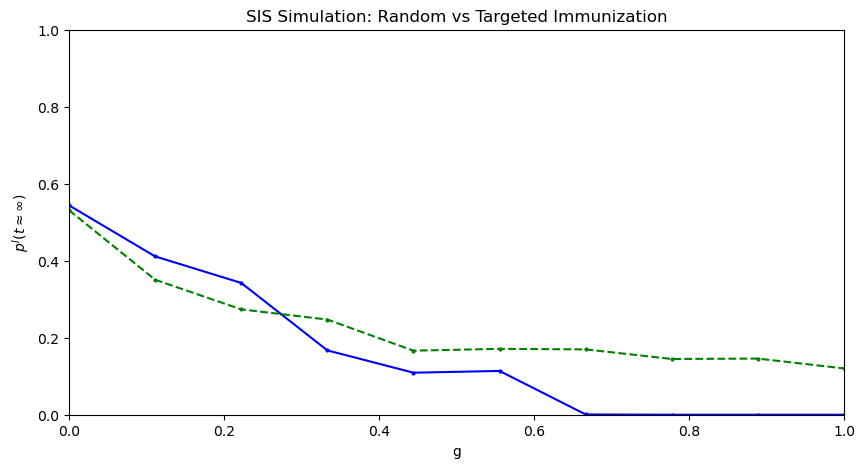

In [30]:
plot_sis_sim()
plt.show()